# 02 · Transformer Encoder — Baseline (unoptimized)
**ICT-4442 HAR comparison · Model 4 of 4 · Owner: K V Ananth Karantha**

Trains a plain Transformer encoder on the raw 9-channel, 128-step inertial windows produced by `01_HAR_Preprocessing.ipynb`, then:
- evaluates it with the **shared** `har_common` metrics (identical to the MLP, CNN and LSTM runs),
- measures efficiency (parameters, size, FLOPs, CPU/GPU latency, training time),
- exports **runnable model files** (TorchScript + ONNX, with clipping/normalization built in) and a `predict.py` script,
- appends its row to the team's `results/comparison_table.csv`.

**Before running:** `01_HAR_Preprocessing.ipynb` must have been run once. Set **Runtime → Change runtime type → T4 GPU** (CPU works but is ~10× slower).

"Baseline" means sensible defaults with no tuning: no augmentation, no class weights, no LR schedule. Tuning comes later (work plan step 6) as `run_tag="tuned"`.

## 0 · Setup

In [13]:
!pip -q install onnx onnxruntime

import os, sys, json, time, copy, glob, subprocess
import numpy as np
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

PROJECT_DIR = os.environ.get("HAR_PROJECT_DIR", "/content/drive/MyDrive/DL Proj")
try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    pass

PROC_DIR = os.path.join(PROJECT_DIR, "processed")
assert os.path.isfile(os.path.join(PROC_DIR, "har_common.py")), "Run 01_HAR_Preprocessing.ipynb first."
sys.path.insert(0, PROC_DIR)
import har_common as hc

MODEL_NAME, FAMILY, OWNER, RUN_TAG = "transformer", "Transformer", "K V Ananth Karantha", "baseline"
MODEL_DIR = os.path.join(PROJECT_DIR, "models", MODEL_NAME, RUN_TAG)
os.makedirs(MODEL_DIR, exist_ok=True)

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
torch.backends.cudnn.benchmark = False
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"
print(f"Device: {DEVICE} {torch.cuda.get_device_name(0) if USE_AMP else ''} | torch {torch.__version__}")
print(f"Dataset version: {hc.DATASET_VERSION} | classes: {hc.CLASSES}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda Tesla T4 | torch 2.11.0+cu130
Dataset version: uci-har-65a1fc6120e8 | classes: ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']


## 1 · Hyperparameters (baseline defaults — deliberately untuned)

In [14]:
HP = dict(
    d_model=64, n_heads=4, n_layers=2, d_ff=128, dropout=0.1,   # architecture
    pooling="cls", positional="learned",
    batch_size=64, lr=1e-3, weight_decay=1e-2, optimizer="AdamW",
    epochs=150, early_stopping_patience=20, grad_clip=1.0,
    augmentation=False, class_weights=False, lr_schedule=None,
)
HP

{'d_model': 64,
 'n_heads': 4,
 'n_layers': 2,
 'd_ff': 128,
 'dropout': 0.1,
 'pooling': 'cls',
 'positional': 'learned',
 'batch_size': 64,
 'lr': 0.001,
 'weight_decay': 0.01,
 'optimizer': 'AdamW',
 'epochs': 150,
 'early_stopping_patience': 20,
 'grad_clip': 1.0,
 'augmentation': False,
 'class_weights': False,
 'lr_schedule': None}

## 2 · Load the shared preprocessed data

In [15]:
data = hc.load_data("sequence", augmented_train=HP["augmentation"])
for sp in ("train", "val", "test"):
    print(f"{sp:5s} X {data[f'X_{sp}'].shape}  y {np.bincount(data[f'y_{sp}'], minlength=6)}")

SEQ_LEN, N_CH = data["X_train"].shape[1:]
g = torch.Generator().manual_seed(SEED)
train_dl = DataLoader(TensorDataset(torch.from_numpy(data["X_train"]), torch.from_numpy(data["y_train"]).long()),
                      batch_size=HP["batch_size"], shuffle=True, generator=g, drop_last=False)

train X (5974, 128, 9)  y [ 997  866  795 1055 1113 1148]
val   X (1378, 128, 9)  y [229 207 191 231 261 259]
test  X (2947, 128, 9)  y [496 471 420 491 532 537]


## 3 · Model
```
(B, 128, 9) ──Linear──▶ (B, 128, d) ──prepend [CLS]──▶ (B, 129, d) ──+ learned positions
            ──▶ N × [ LayerNorm → Multi-Head Self-Attention → + ] [ LayerNorm → FFN(GELU) → + ]
            ──▶ LayerNorm([CLS]) ──Linear──▶ 6 logits
```
Each of the 128 timesteps (20 ms of all 9 sensor channels) is one token, so self-attention can relate any two moments of the 2.56 s window directly — the property the synopsis contrasts with the CNN's local receptive field and the LSTM's sequential state.

In [16]:
class HARTransformer(nn.Module):
    def __init__(self, n_channels=9, seq_len=128, n_classes=6, d_model=64, n_heads=4,
                 n_layers=2, d_ff=128, dropout=0.1, **_):
        super().__init__()
        self.input_proj = nn.Linear(n_channels, d_model)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.zeros(1, seq_len + 1, d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02); nn.init.trunc_normal_(self.cls_token, std=0.02)
        layer = nn.TransformerEncoderLayer(d_model, n_heads, d_ff, dropout, activation="gelu",
                                           batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(layer, n_layers, enable_nested_tensor=False)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, n_classes)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):                      # x: (B, T, C) normalized signals
        h = self.input_proj(x)
        h = torch.cat([self.cls_token.expand(h.shape[0], -1, -1), h], dim=1) + self.pos_embed
        h = self.encoder(self.drop(h))
        return self.head(self.norm(h[:, 0]))   # logits

model = HARTransformer(N_CH, SEQ_LEN, hc.N_CLASSES, **HP).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model); print(f"\nParameters: {n_params:,} (trainable {n_train:,})")

HARTransformer(
  (input_proj): Linear(in_features=9, out_features=64, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=64, out_features=6, bias=True)
  (drop): Dropout(p=0.1, inplace=False)
)

Parameters: 76,422 (trainable 76,422)


## 4 · Training
Early stopping and model selection use **validation macro-F1** (the team's primary metric). The test set is not touched until section 6.

In [17]:
from sklearn.metrics import f1_score, accuracy_score, log_loss

@torch.no_grad()
def predict_proba(m, X, bs=512):
    m.eval(); out = []
    for i in range(0, len(X), bs):
        xb = torch.from_numpy(X[i:i + bs]).to(DEVICE)
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
            logits = m(xb)
        out.append(torch.softmax(logits.float(), 1).cpu().numpy())
    return np.concatenate(out)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=HP["lr"], weight_decay=HP["weight_decay"])
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
if USE_AMP: torch.cuda.reset_peak_memory_stats()

history, best_f1, best_state, best_epoch, bad = [], -1, None, 0, 0
t_train = time.time()
for epoch in range(1, HP["epochs"] + 1):
    model.train(); t0 = time.time(); loss_sum = correct = seen = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
            logits = model(xb); loss = criterion(logits, yb)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer); nn.utils.clip_grad_norm_(model.parameters(), HP["grad_clip"])
        scaler.step(optimizer); scaler.update()
        loss_sum += loss.item() * len(yb); correct += (logits.argmax(1) == yb).sum().item(); seen += len(yb)

    pv = predict_proba(model, data["X_val"]); yv = data["y_val"]
    row = dict(epoch=epoch, train_loss=loss_sum / seen, train_acc=correct / seen,
               val_loss=log_loss(yv, np.clip(pv, 1e-7, 1), labels=range(6)),
               val_acc=accuracy_score(yv, pv.argmax(1)), val_macro_f1=f1_score(yv, pv.argmax(1), average="macro"),
               lr=optimizer.param_groups[0]["lr"], epoch_time_s=time.time() - t0)
    history.append(row)
    improved = row["val_macro_f1"] > best_f1
    if improved:
        best_f1, best_epoch, bad = row["val_macro_f1"], epoch, 0
        best_state = copy.deepcopy(model.state_dict())
    else:
        bad += 1
    print(f"ep {epoch:3d} | loss {row['train_loss']:.4f} acc {row['train_acc']:.4f} | "
          f"val loss {row['val_loss']:.4f} acc {row['val_acc']:.4f} F1 {row['val_macro_f1']:.4f} | "
          f"{row['epoch_time_s']:.1f}s {'*' if improved else ''}")
    if bad >= HP["early_stopping_patience"]:
        print(f"Early stopping: no val macro-F1 improvement for {bad} epochs."); break

train_time = time.time() - t_train
model.load_state_dict(best_state)
TRAINING = dict(train_time_s=round(train_time, 2), epochs_trained=len(history), best_epoch=best_epoch,
                time_per_epoch_s=round(float(np.mean([h["epoch_time_s"] for h in history])), 3),
                best_val_macro_f1=best_f1, early_stopping=f"patience {HP['early_stopping_patience']} on val macro-F1",
                peak_gpu_mem_mb=round(torch.cuda.max_memory_allocated() / 2**20, 1) if USE_AMP else None)
print(f"\nBest epoch {best_epoch}  val macro-F1 {best_f1:.4f}  |  {train_time:.0f}s total")

ep   1 | loss 0.3988 acc 0.8577 | val loss 0.1940 acc 0.9245 F1 0.9241 | 1.2s *
ep   2 | loss 0.1658 acc 0.9392 | val loss 0.2603 acc 0.9158 F1 0.9138 | 1.7s 
ep   3 | loss 0.1490 acc 0.9394 | val loss 0.1867 acc 0.9151 F1 0.9137 | 3.3s 
ep   4 | loss 0.1376 acc 0.9402 | val loss 0.1810 acc 0.9238 F1 0.9230 | 2.0s 
ep   5 | loss 0.1223 acc 0.9484 | val loss 0.2268 acc 0.9122 F1 0.9104 | 1.6s 
ep   6 | loss 0.1074 acc 0.9533 | val loss 0.1723 acc 0.9354 F1 0.9346 | 1.9s *
ep   7 | loss 0.1086 acc 0.9526 | val loss 0.1201 acc 0.9405 F1 0.9425 | 2.1s *
ep   8 | loss 0.0980 acc 0.9571 | val loss 0.1772 acc 0.9303 F1 0.9306 | 2.5s 
ep   9 | loss 0.0923 acc 0.9587 | val loss 0.1880 acc 0.9347 F1 0.9336 | 3.4s 
ep  10 | loss 0.0985 acc 0.9570 | val loss 0.4872 acc 0.8628 F1 0.8555 | 2.4s 
ep  11 | loss 0.0876 acc 0.9605 | val loss 0.1119 acc 0.9565 F1 0.9572 | 1.7s *
ep  12 | loss 0.0846 acc 0.9633 | val loss 0.1556 acc 0.9361 F1 0.9363 | 0.9s 
ep  13 | loss 0.0716 acc 0.9675 | val loss 0.122

### Learning curves

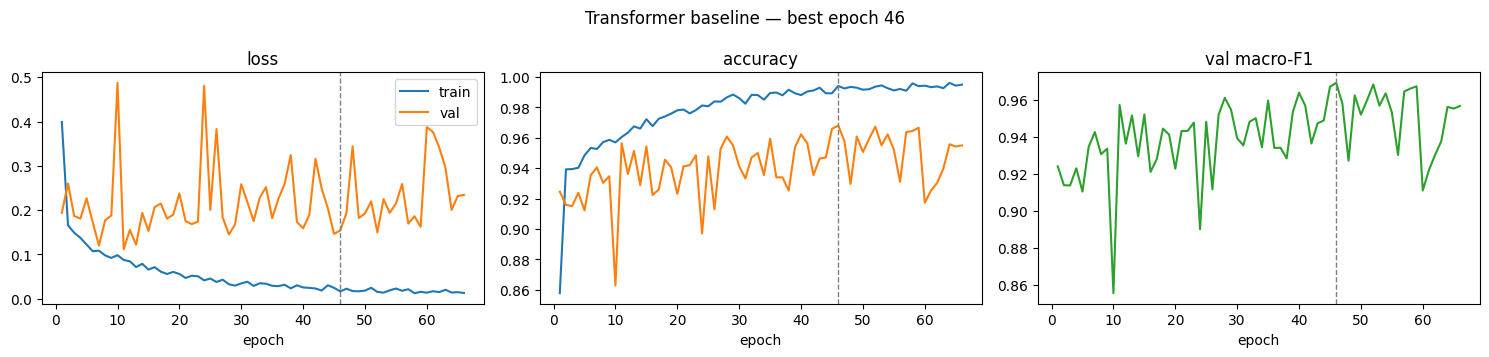

In [18]:
import matplotlib.pyplot as plt
RESULT_DIR = os.path.join(hc.RESULTS_DIR, MODEL_NAME, RUN_TAG); os.makedirs(RESULT_DIR, exist_ok=True)
ep = [h["epoch"] for h in history]
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
ax[0].plot(ep, [h["train_loss"] for h in history], label="train"); ax[0].plot(ep, [h["val_loss"] for h in history], label="val"); ax[0].set_title("loss")
ax[1].plot(ep, [h["train_acc"] for h in history], label="train"); ax[1].plot(ep, [h["val_acc"] for h in history], label="val"); ax[1].set_title("accuracy")
ax[2].plot(ep, [h["val_macro_f1"] for h in history], color="C2"); ax[2].set_title("val macro-F1")
for a in ax:
    a.axvline(best_epoch, ls="--", c="grey", lw=1); a.set_xlabel("epoch")
ax[0].legend(); fig.suptitle(f"Transformer baseline — best epoch {best_epoch}"); plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "learning_curves.png"), dpi=130); plt.show()

## 5 · Export runnable model files
The deployable model takes **raw** sensor windows `(N, 128, 9)` and returns class probabilities: clipping and normalization (from the shared training statistics) are baked into the graph, so no preprocessing code is needed to use it.

In [19]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="torch")       # jit deprecation notices
warnings.filterwarnings("ignore", category=DeprecationWarning, message=".*TorchScript-based ONNX.*")
if hasattr(torch.backends, "mha") and hasattr(torch.backends.mha, "set_fastpath_enabled"):
    torch.backends.mha.set_fastpath_enabled(False)   # plain ops -> clean export + accurate FLOP count

norm = hc.SEQ_NORM
class DeployModel(nn.Module):
    """raw (N,128,9) -> clip -> z-score -> transformer -> softmax probabilities (N,6)"""
    def __init__(self, net):
        super().__init__()
        self.net = net
        for k in ("clip_lo", "clip_hi", "mean", "std"):
            self.register_buffer(k, torch.tensor(norm[k], dtype=torch.float32))
    def forward(self, x):
        x = torch.maximum(torch.minimum(x, self.clip_hi), self.clip_lo)
        return torch.softmax(self.net((x - self.mean) / self.std), dim=-1)

model_cpu = copy.deepcopy(model).cpu().eval()
deploy = DeployModel(model_cpu).eval()
raw_test = data["X_test"] * np.array(norm["std"], np.float32) + np.array(norm["mean"], np.float32)
example = torch.from_numpy(raw_test[:2])
ref = deploy(example).detach().numpy()

ARTIFACTS = {}
p = os.path.join(MODEL_DIR, "transformer_state_dict.pt"); torch.save(model_cpu.state_dict(), p); ARTIFACTS["state_dict"] = p
cfg = {"model": "HARTransformer", "hyperparameters": HP, "input": {"shape": ["N", int(SEQ_LEN), int(N_CH)], "units": "raw UCI HAR inertial signals",
       "channel_order": hc.SIGNALS}, "output": {"type": "probabilities", "classes": hc.CLASSES},
       "normalization": norm, "dataset_version": hc.DATASET_VERSION, "best_epoch": best_epoch}
p = os.path.join(MODEL_DIR, "model_config.json"); json.dump(cfg, open(p, "w"), indent=2); ARTIFACTS["config"] = p

# TorchScript: one self-contained file, loadable with torch.jit.load — no class definition needed
try:
    ts = torch.jit.trace(deploy, example, check_trace=False)
    p = os.path.join(MODEL_DIR, "transformer_deploy.torchscript.pt"); ts.save(p)
    err = np.abs(torch.jit.load(p)(example).detach().numpy() - ref).max()
    ARTIFACTS["torchscript"] = p; print(f"TorchScript saved  (max |diff| vs PyTorch = {err:.2e})")
except Exception as e:
    print("TorchScript export skipped:", repr(e)[:200])

# ONNX: framework-independent, runs with onnxruntime on any device
try:
    p = os.path.join(MODEL_DIR, "transformer_deploy.onnx")
    kw = dict(input_names=["raw_window"], output_names=["probabilities"], opset_version=17,
              dynamic_axes={"raw_window": {0: "batch"}, "probabilities": {0: "batch"}})
    try:
        torch.onnx.export(deploy, (example,), p, dynamo=False, **kw)
    except TypeError:
        torch.onnx.export(deploy, (example,), p, **kw)
    import onnxruntime as ort
    sess = ort.InferenceSession(p, providers=["CPUExecutionProvider"])
    err = np.abs(sess.run(None, {"raw_window": raw_test[:2]})[0] - ref).max()
    ARTIFACTS["onnx"] = p; print(f"ONNX saved         (max |diff| vs PyTorch = {err:.2e})")
except Exception as e:
    print("ONNX export skipped:", repr(e)[:300])

TorchScript saved  (max |diff| vs PyTorch = 0.00e+00)
ONNX saved         (max |diff| vs PyTorch = 3.49e-10)


### Stand-alone prediction script
`predict.py` runs the exported model on new data with nothing but PyTorch (or onnxruntime) installed.

In [20]:
%%writefile "{MODEL_DIR}/predict.py"
"""Run the exported HAR Transformer on raw smartphone sensor windows.

  python predict.py --uci-dir "path/to/UCI HAR Dataset/test"   # reads Inertial Signals (+ y_test.txt if present)
  python predict.py --npy windows.npy                          # raw windows, shape (N, 128, 9)
  add --onnx to use onnxruntime instead of PyTorch
Channel order: body_acc_x/y/z, body_gyro_x/y/z, total_acc_x/y/z (see model_config.json).
"""
import argparse, json, os, sys, time
import numpy as np

HERE = os.path.dirname(os.path.abspath(__file__))
CFG = json.load(open(os.path.join(HERE, "model_config.json")))
CLASSES = CFG["output"]["classes"]; SIGNALS = CFG["input"]["channel_order"]


def load_uci_split(split_dir):
    split = os.path.basename(os.path.normpath(split_dir))
    X = np.stack([np.loadtxt(os.path.join(split_dir, "Inertial Signals", f"{s}_{split}.txt")) for s in SIGNALS], -1)
    y_path = os.path.join(split_dir, f"y_{split}.txt")
    y = np.loadtxt(y_path, dtype=int) - 1 if os.path.exists(y_path) else None
    return X.astype(np.float32), y


def predict(X, use_onnx=False):
    if use_onnx:
        import onnxruntime as ort
        sess = ort.InferenceSession(os.path.join(HERE, "transformer_deploy.onnx"), providers=["CPUExecutionProvider"])
        return np.concatenate([sess.run(None, {"raw_window": X[i:i + 512]})[0] for i in range(0, len(X), 512)])
    import torch
    m = torch.jit.load(os.path.join(HERE, "transformer_deploy.torchscript.pt"), map_location="cpu").eval()
    with torch.no_grad():
        return np.concatenate([m(torch.from_numpy(X[i:i + 512])).numpy() for i in range(0, len(X), 512)])


if __name__ == "__main__":
    ap = argparse.ArgumentParser()
    g = ap.add_mutually_exclusive_group(required=True)
    g.add_argument("--uci-dir"); g.add_argument("--npy")
    ap.add_argument("--onnx", action="store_true"); ap.add_argument("--out", help="optional CSV of predictions")
    a = ap.parse_args()
    X, y = load_uci_split(a.uci_dir) if a.uci_dir else (np.load(a.npy).astype(np.float32), None)
    assert X.ndim == 3 and X.shape[1:] == (128, 9), f"expected (N,128,9), got {X.shape}"
    t0 = time.time(); P = predict(X, a.onnx); dt = time.time() - t0
    pred = P.argmax(1)
    print(f"{len(X)} windows in {dt:.2f}s ({'onnx' if a.onnx else 'torchscript'})")
    for i, c in enumerate(CLASSES):
        print(f"  {c:20s} {int((pred == i).sum()):5d}")
    if y is not None:
        print(f"accuracy vs labels: {(pred == y).mean():.4f}")
    if a.out:
        import csv
        with open(a.out, "w", newline="") as f:
            w = csv.writer(f); w.writerow(["window", "predicted"] + [f"p_{c}" for c in CLASSES])
            for i, (k, p) in enumerate(zip(pred, P)):
                w.writerow([i, CLASSES[k]] + [f"{v:.5f}" for v in p])
        print("saved", a.out)

Writing /content/drive/MyDrive/DL Proj/models/transformer/baseline/predict.py


In [21]:
ARTIFACTS["predict_script"] = os.path.join(MODEL_DIR, "predict.py")
hits = [h for h in glob.glob(os.path.join(PROJECT_DIR, "dataset", "**", "Inertial Signals"), recursive=True) if h.rstrip("/").endswith("test/Inertial Signals")]
if hits and "torchscript" in ARTIFACTS:
    test_dir = os.path.dirname(hits[0])
    print("Running predict.py on the original raw test files (end-to-end check):")
    r = subprocess.run([sys.executable, ARTIFACTS["predict_script"], "--uci-dir", test_dir], capture_output=True, text=True)
    print(r.stdout or r.stderr)

Running predict.py on the original raw test files (end-to-end check):
2947 windows in 13.50s (torchscript)
  WALKING                445
  WALKING_UPSTAIRS       450
  WALKING_DOWNSTAIRS     495
  SITTING                432
  STANDING               582
  LAYING                 543
accuracy vs labels: 0.9284



## 6 · Final evaluation and efficiency

In [22]:
from torch.utils.flop_counter import FlopCounterMode
p_train = predict_proba(model, data["X_train"])
p_val   = predict_proba(model, data["X_val"])
p_test  = predict_proba(model, data["X_test"])          # first and only use of the test set

with FlopCounterMode(display=False) as fc:
    model_cpu(torch.from_numpy(data["X_test"][:1]))
flops = int(fc.get_total_flops())

x1_cpu = torch.from_numpy(data["X_test"][:1])
with torch.inference_mode():
    cpu = hc.measure_latency(lambda x: model_cpu(x).numpy(), x1_cpu)
gpu = {}
if USE_AMP:
    model.eval()
    xb1, xb256 = x1_cpu.to(DEVICE), torch.from_numpy(data["X_test"][:256]).to(DEVICE)
    with torch.inference_mode():
        gpu = hc.measure_latency(lambda x: model(x).cpu(), xb1, xb256)

EFFICIENCY = dict(
    params_total=n_params, params_trainable=n_train,
    model_size_mb=round(os.path.getsize(ARTIFACTS["state_dict"]) / 2**20, 3),
    flops_per_window=flops, flops_tool="torch.utils.flop_counter (2 x MACs)",
    latency_ms_cpu_b1=round(cpu["latency_ms_b1_mean"], 3), latency_ms_cpu_b1_p95=round(cpu["latency_ms_b1_p95"], 3),
    cpu_threads=torch.get_num_threads(),
    latency_ms_gpu_b1=round(gpu["latency_ms_b1_mean"], 3) if gpu else None,
    throughput_gpu_wps=round(gpu["throughput_wps"], 1) if gpu else None,
    peak_gpu_mem_mb=TRAINING["peak_gpu_mem_mb"])
EFFICIENCY

{'params_total': 76422,
 'params_trainable': 76422,
 'model_size_mb': 0.303,
 'flops_per_window': 17056512,
 'flops_tool': 'torch.utils.flop_counter (2 x MACs)',
 'latency_ms_cpu_b1': 3.006,
 'latency_ms_cpu_b1_p95': 4.186,
 'cpu_threads': 1,
 'latency_ms_gpu_b1': 2.523,
 'throughput_gpu_wps': 25413.9,
 'peak_gpu_mem_mb': 119.5}

## 7 · Record results (shared format)

Saved transformer__baseline__20261002-054215
  details -> /content/drive/MyDrive/DL Proj/results/transformer/baseline
  table   -> /content/drive/MyDrive/DL Proj/results/comparison_table.csv

TEST  accuracy 0.9284 | macro-F1 0.9268 | kappa 0.9140 | sit/stand confusion 0.086 | worst subject acc 0.721
VAL   macro-F1 0.9691 | TRAIN macro-F1 0.9974
                    precision    recall  f1-score   support

           WALKING     0.9640    0.8649    0.9118       496
  WALKING_UPSTAIRS     0.9533    0.9108    0.9316       471
WALKING_DOWNSTAIRS     0.8384    0.9881    0.9071       420
           SITTING     0.9560    0.8411    0.8949       491
          STANDING     0.8814    0.9643    0.9210       532
            LAYING     0.9890    1.0000    0.9944       537

          accuracy                         0.9284      2947
         macro avg     0.9304    0.9282    0.9268      2947
      weighted avg     0.9327    0.9284    0.9282      2947



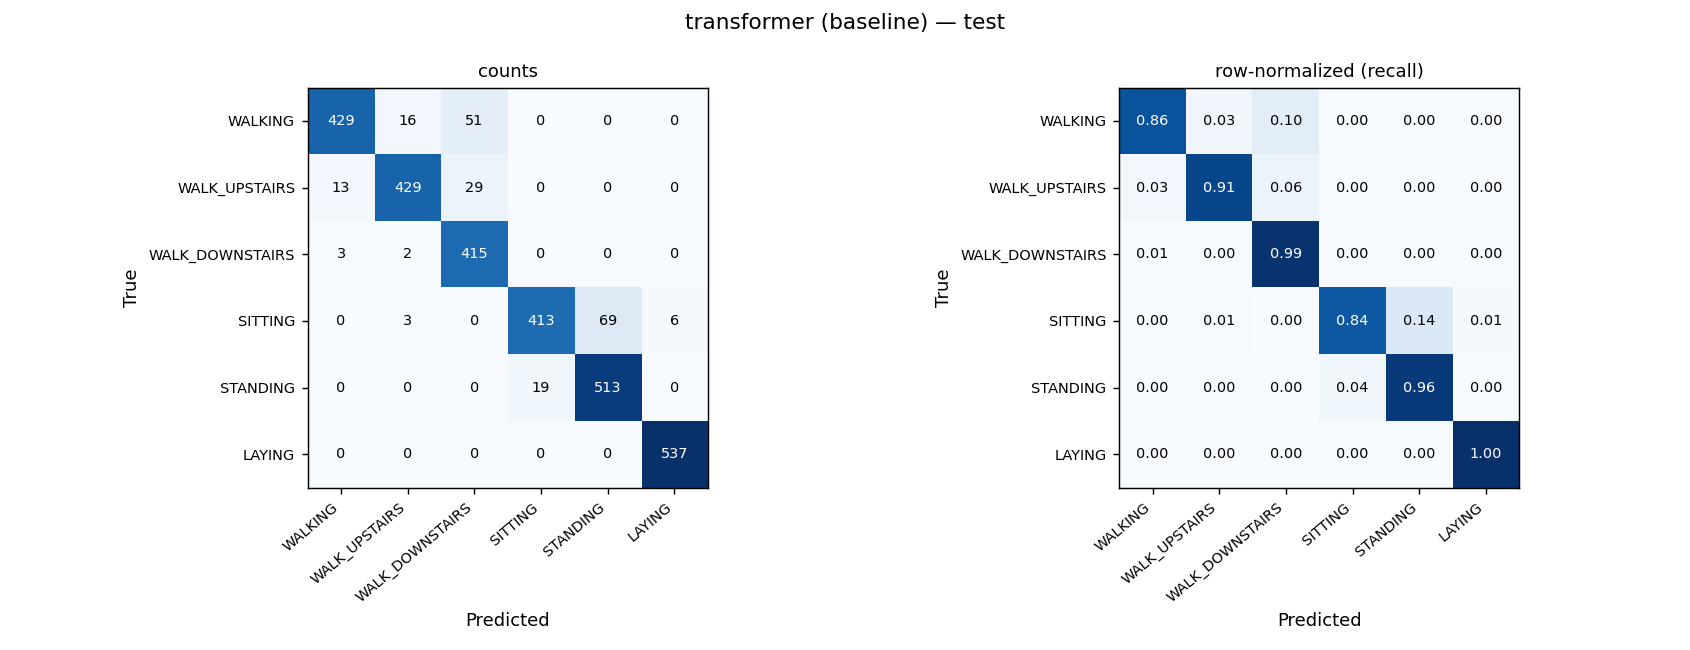

In [23]:
record = hc.save_results(
    model_name=MODEL_NAME, family=FAMILY, owner=OWNER, input_representation="raw_9ch_128", run_tag=RUN_TAG,
    y_test=data["y_test"], p_test=p_test, s_test=data["s_test"],
    y_val=data["y_val"], p_val=p_val, y_train=data["y_train"], p_train=p_train,
    efficiency=EFFICIENCY, training=TRAINING, hyperparameters=HP, history=history,
    framework=f"PyTorch {torch.__version__}", artifacts=ARTIFACTS, seed=SEED,
    notes="Unoptimized baseline: no augmentation, no class weights, constant LR; FLOPs via torch flop_counter.")

t = record["test"]
print(f"\nTEST  accuracy {t['accuracy']:.4f} | macro-F1 {t['macro_f1']:.4f} | kappa {t['cohen_kappa']:.4f} | "
      f"sit/stand confusion {t['sit_stand_confusion_rate']:.3f} | worst subject acc {t['subject_acc_min']:.3f}")
print(f"VAL   macro-F1 {record['val']['macro_f1']:.4f} | TRAIN macro-F1 {record['train']['macro_f1']:.4f}")
print(open(os.path.join(RESULT_DIR, "classification_report.txt")).read())
from IPython.display import Image, display
display(Image(os.path.join(RESULT_DIR, "confusion_matrix.png")))

In [24]:
import pandas as pd
table = pd.read_csv(os.path.join(hc.RESULTS_DIR, "comparison_table.csv"))
cols = ["model_name", "run_tag", "owner", "test_accuracy", "test_macro_f1", "test_cohen_kappa",
        "sit_stand_confusion_rate", "walking_variants_confusion_rate", "subject_acc_min",
        "params_total", "model_size_mb", "latency_ms_cpu_b1", "train_time_s"]
table[cols].round(4)

,model_name,run_tag,owner,test_accuracy,test_macro_f1,test_cohen_kappa,sit_stand_confusion_rate,walking_variants_confusion_rate,subject_acc_min,params_total,model_size_mb,latency_ms_cpu_b1,train_time_s
0,transformer,baseline,K V Ananth Karantha,0.9284,0.9268,0.914,0.086,0.0822,0.7211,76422,0.303,3.006,76.9


## Outputs
| Where | What |
|---|---|
| `DL Proj/models/transformer/baseline/` | `transformer_deploy.torchscript.pt`, `transformer_deploy.onnx` (raw input → probabilities), `transformer_state_dict.pt`, `model_config.json`, `predict.py` |
| `DL Proj/results/transformer/baseline/` | `metrics.json` (everything), `history.csv`, `classification_report.txt`, `confusion_matrix.png`, `learning_curves.png` |
| `DL Proj/results/comparison_table.csv` | one row per run, shared by all four models |

Use the exported model anywhere:
```bash
python "DL Proj/models/transformer/baseline/predict.py" --uci-dir "DL Proj/dataset/UCI HAR Dataset/test"
```
Re-running this notebook adds a new row (with a new `run_id`) rather than overwriting the old one. For the tuned version, change `RUN_TAG = "tuned"` and the `HP` values.